# Tramway Battery Storage Optimization

This notebook studies the sizing and control of an onboard battery for a DC tramway system.
The goal is to reduce voltage drops at the train terminals while keeping the battery capacity as small as possible.

The analysis follows a reproducible workflow:

1. Load the train motion profile.
2. Simulate the baseline system without battery.
3. Add a rule-based onboard battery controller.
4. Explore the design space using Monte Carlo sampling.
5. Approximate the Pareto front using a simplified NSGA-II-inspired genetic algorithm.
6. Discuss the engineering trade-off.


In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

# Allow running the notebook directly from the repository root or from notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from tramway_optimization.data import load_train_run
from tramway_optimization.models import BatteryConfig, ElectricalNetwork, TrainConfig
from tramway_optimization.simulation import simulate_without_battery, simulate_with_battery
from tramway_optimization.optimization import monte_carlo_search, simplified_nsga2_search


In [2]:
COLORS = {
    "background": "#0B1020",
    "surface": "#111827",
    "grid": "#334155",

    "baseline": "#94A3B8",   # slate gray
    "train": "#38BDF8",      # cyan
    "line": "#818CF8",       # indigo
    "battery": "#A78BFA",    # violet
    "pareto": "#F472B6",     # pink accent
    "highlight": "#22D3EE",  # bright cyan
    "warning": "#FBBF24",    # amber
}

plt.rcParams.update({
    "figure.facecolor": COLORS["background"],
    "axes.facecolor": COLORS["surface"],
    "axes.edgecolor": COLORS["grid"],
    "axes.labelcolor": "#E5E7EB",
    "xtick.color": "#CBD5E1",
    "ytick.color": "#CBD5E1",
    "text.color": "#E5E7EB",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.facecolor": COLORS["surface"],
    "legend.edgecolor": COLORS["grid"],
    "grid.color": COLORS["grid"],
    "grid.alpha": 0.35,
})

## 1. Data loading

The input file `marche.txt` contains the train motion profile as two columns:

- time in seconds,
- train position in meters.

The velocity and acceleration are computed numerically from this position profile.


In [3]:
DATA_PATH = PROJECT_ROOT / "data" / "marche.txt"

time_s, position_m = load_train_run(DATA_PATH)

print(f"Number of samples: {len(time_s)}")
print(f"Trip duration: {time_s[-1]:.0f} s")
print(f"Line length: {position_m.max() / 1000:.2f} km")


Number of samples: 634
Trip duration: 633 s
Line length: 4.99 km


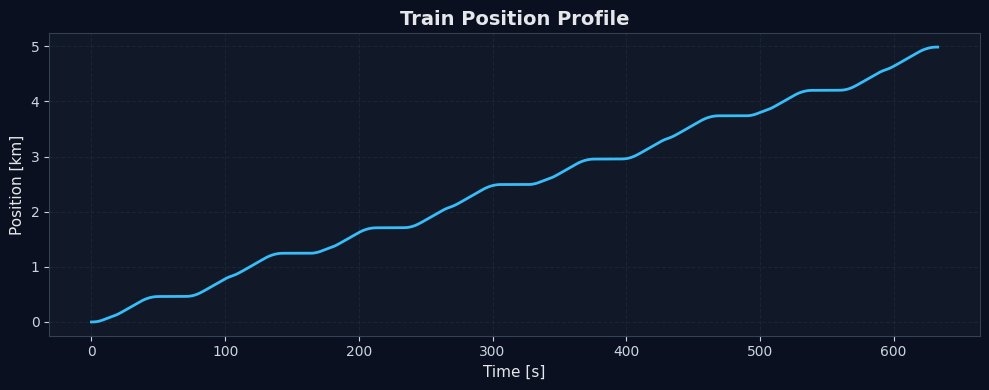

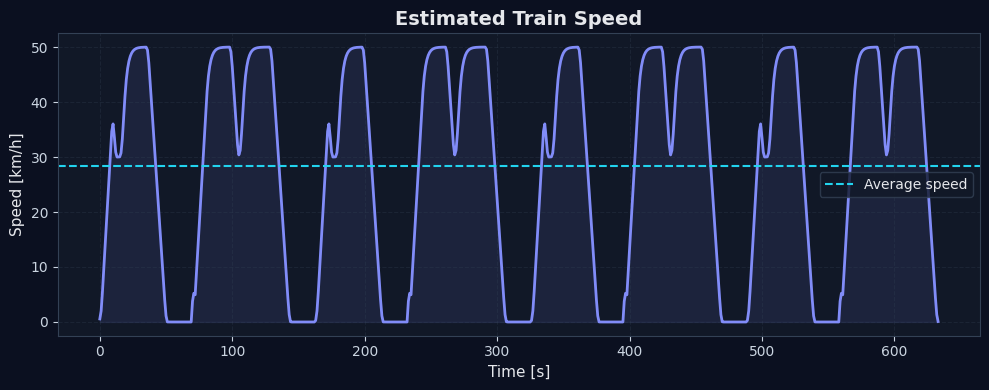

In [4]:
speed_m_per_s = np.gradient(position_m, time_s)

# --- Position ---
plt.figure(figsize=(10, 4))
plt.plot(
    time_s,
    position_m / 1000,
    color=COLORS["train"],
    linewidth=2
)

plt.xlabel("Time [s]")
plt.ylabel("Position [km]")
plt.title("Train Position Profile")

plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()


# --- Speed ---
plt.figure(figsize=(10, 4))

speed_kmh = speed_m_per_s * 3.6

plt.plot(time_s, speed_kmh, color=COLORS["line"], linewidth=2)

plt.fill_between(
    time_s,
    speed_kmh,
    color=COLORS["line"],
    alpha=0.1
)

plt.xlabel("Time [s]")
plt.ylabel("Speed [km/h]")
plt.title("Estimated Train Speed")

plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

plt.axhline(
    speed_kmh.mean(),
    color=COLORS["highlight"],
    linestyle="--",
    label="Average speed"
)

plt.legend()

## 2. Baseline simulation without battery

The first simulation evaluates the tramway electrical network without onboard storage.

During traction phases, the line supplies the train.
During braking phases, regenerative energy is not recovered and is assumed to be dissipated.


In [5]:
network = ElectricalNetwork()
train = TrainConfig()

baseline = simulate_without_battery(time_s, position_m, network=network, train=train)

print(f"Maximum voltage drop without battery: {baseline.max_voltage_drop_v:.1f} V")
print(f"Minimum train voltage without battery: {baseline.train_voltage_v.min():.1f} V")


Maximum voltage drop without battery: 350.2 V
Minimum train voltage without battery: 439.8 V


Text(321.0, 469.7603191678422, 'Min: 440 V')

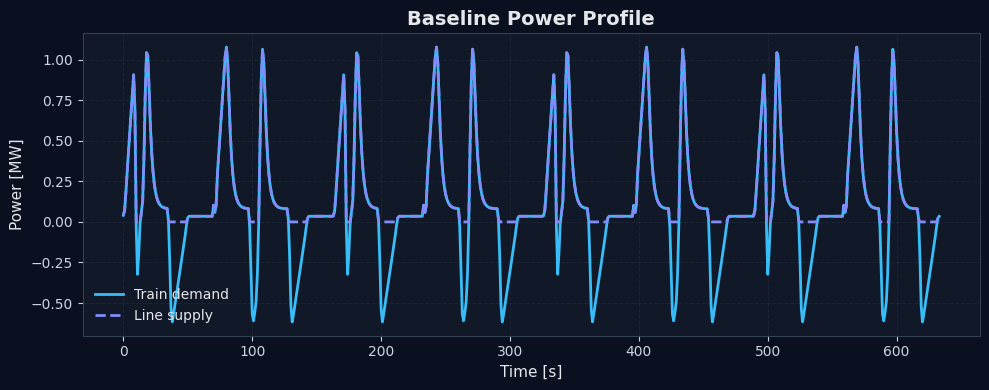

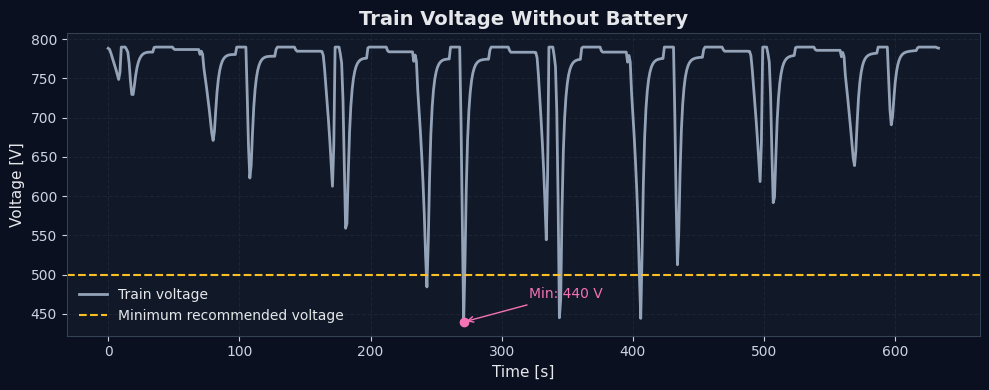

In [6]:
# --- Power profile ---
plt.figure(figsize=(10, 4))

plt.plot(
    time_s,
    baseline.train_power_w / 1e6,
    color=COLORS["train"],
    linewidth=2,
    label="Train demand"
)

plt.plot(
    time_s,
    baseline.line_power_w / 1e6,
    color=COLORS["line"],
    linewidth=2,
    linestyle="--",
    label="Line supply"
)

plt.xlabel("Time [s]")
plt.ylabel("Power [MW]")
plt.title("Baseline Power Profile")

plt.legend(frameon=False)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()


# --- Voltage profile ---
plt.figure(figsize=(10, 4))

plt.plot(
    time_s,
    baseline.train_voltage_v,
    color=COLORS["baseline"],
    linewidth=2,
    label="Train voltage"
)

plt.axhline(
    500,
    color=COLORS["warning"],
    linestyle="--",
    linewidth=1.5,
    label="Minimum recommended voltage"
)

# Highlight unsafe zone
plt.fill_between(
    time_s,
    baseline.train_voltage_v,
    500,
    where=(baseline.train_voltage_v < 500),
    color=COLORS["warning"],
    alpha=0.15,
)

plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.title("Train Voltage Without Battery")

plt.legend(frameon=False)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

min_v = baseline.train_voltage_v.min()
t_min = time_s[baseline.train_voltage_v.argmin()]

plt.scatter(t_min, min_v, color=COLORS["pareto"], zorder=5)

plt.annotate(
    f"Min: {min_v:.0f} V",
    (t_min, min_v),
    xytext=(t_min + 50, min_v + 30),
    arrowprops=dict(arrowstyle="->", color=COLORS["pareto"]),
    color=COLORS["pareto"]
)

## 3. Battery-assisted simulation

The onboard battery uses a simple rule-based strategy:

- if the train is braking, regenerative power is stored when the battery is not full,
- if the train requires traction power below the threshold, the line supplies all the power,
- if the train requires traction power above the threshold, the battery supplies the excess when possible.

A representative design is tested first: **1.6 kWh** and **400 kW**.


In [7]:
reference_battery = BatteryConfig.from_kwh(
    capacity_kwh=1.6,
    power_threshold_kw=400,
    efficiency=0.90,
    initial_state_of_charge=1.0,
)

battery_result = simulate_with_battery(
    time_s,
    position_m,
    reference_battery,
    network=network,
    train=train,
)

print(f"Maximum voltage drop with battery: {battery_result.max_voltage_drop_v:.1f} V")
print(f"Minimum train voltage with battery: {battery_result.train_voltage_v.min():.1f} V")
print(f"Reduction in max voltage drop: {baseline.max_voltage_drop_v - battery_result.max_voltage_drop_v:.1f} V")


Maximum voltage drop with battery: 83.4 V
Minimum train voltage with battery: 706.6 V
Reduction in max voltage drop: 266.8 V


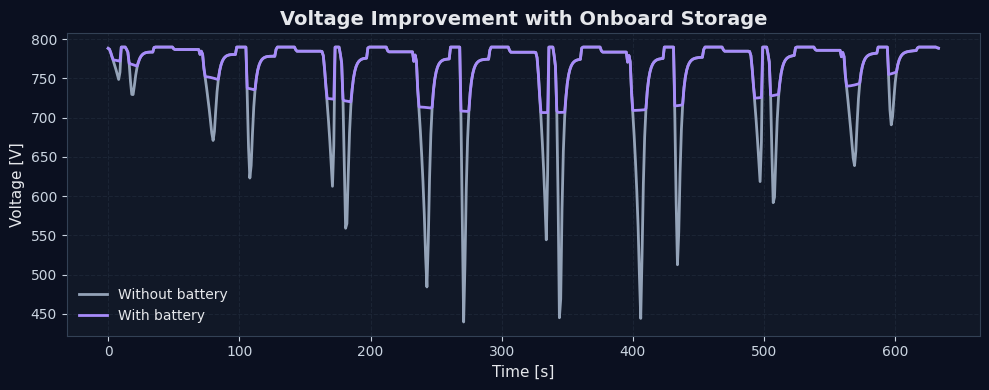

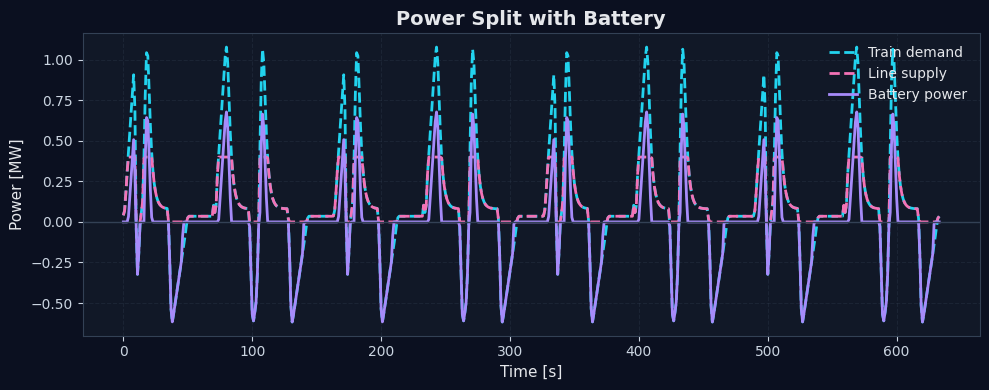

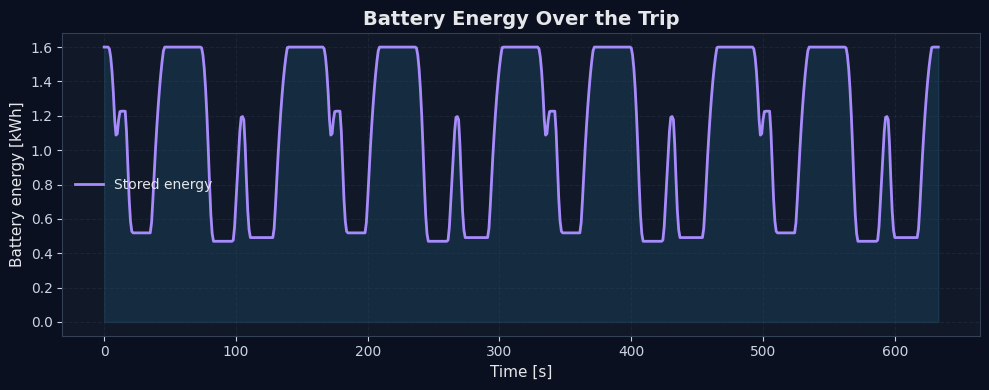

In [8]:
# --- Voltage comparison ---
plt.figure(figsize=(10, 4))

plt.plot(
    time_s,
    baseline.train_voltage_v,
    color=COLORS["baseline"],
    linewidth=2,
    label="Without battery",
)

plt.plot(
    time_s,
    battery_result.train_voltage_v,
    color=COLORS["battery"],
    linewidth=2,
    label="With battery",
)

plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.title("Voltage Improvement with Onboard Storage")

plt.legend(frameon=False)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()


# --- Power split ---
plt.figure(figsize=(10, 4))

plt.plot(
    time_s,
    battery_result.train_power_w / 1e6,
    color=COLORS["highlight"],
    linewidth=2,
    linestyle="--",
    label="Train demand",
)

plt.plot(
    time_s,
    battery_result.line_power_w / 1e6,
    color=COLORS["pareto"],
    linewidth=2,
    linestyle="--",
    label="Line supply",
)

plt.plot(
    time_s,
    battery_result.battery_power_w / 1e6,
    color=COLORS["battery"],
    linewidth=2,
    label="Battery power",
)

plt.axhline(0, color=COLORS["grid"], linewidth=1)

plt.xlabel("Time [s]")
plt.ylabel("Power [MW]")
plt.title("Power Split with Battery")

plt.legend(frameon=False)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()


# --- Battery energy ---
plt.figure(figsize=(10, 4))

battery_energy_kwh = battery_result.battery_energy_j / 3.6e6

plt.plot(
    time_s,
    battery_energy_kwh,
    color=COLORS["battery"],
    linewidth=2,
    label="Stored energy",
)

plt.fill_between(
    time_s,
    battery_energy_kwh,
    color=COLORS["train"],
    alpha=0.12,
)

plt.xlabel("Time [s]")
plt.ylabel("Battery energy [kWh]")
plt.title("Battery Energy Over the Trip")

plt.legend(frameon=False)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

## 4. Monte Carlo design-space exploration

The design variables are:

- battery capacity in kWh,
- line power threshold in kW.

Each sampled design is evaluated by a full time-domain simulation.
The objective space is built from:

- battery capacity,
- maximum voltage drop.

The non-dominated designs form an approximation of the Pareto front.


In [9]:
monte_carlo = monte_carlo_search(
    time_s,
    position_m,
    n_samples=600,
    capacity_bounds_kwh=(0.0, 14.0),
    threshold_bounds_kw=(0.0, 1000.0),
    random_seed=7,
    network=network,
    train=train,
)

print(f"Evaluated designs: {len(monte_carlo.capacities_kwh)}")
print(f"Pareto designs: {len(monte_carlo.pareto_indices)}")


Evaluated designs: 600
Pareto designs: 25


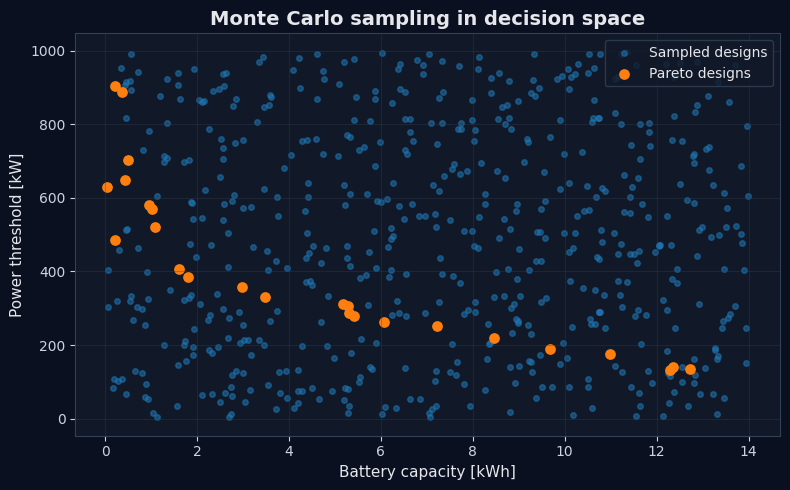

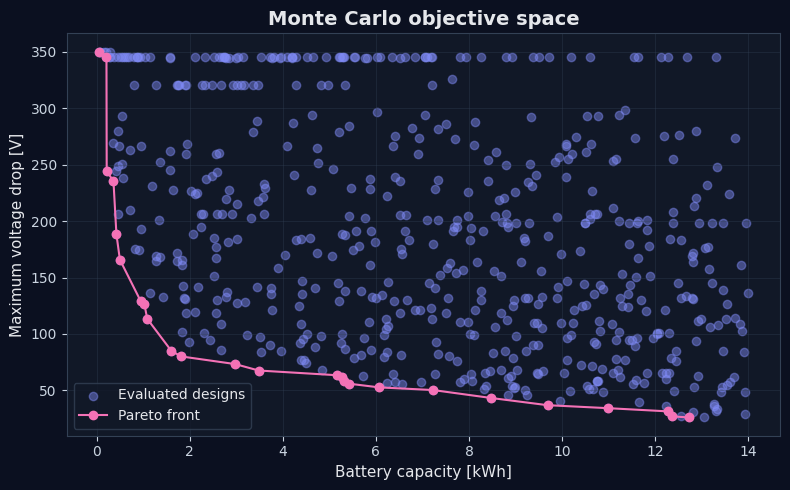

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(
    monte_carlo.capacities_kwh,
    monte_carlo.power_thresholds_kw,
    s=16,
    alpha=0.55,
    label="Sampled designs",
)
plt.scatter(
    monte_carlo.pareto_capacities_kwh,
    monte_carlo.pareto_power_thresholds_kw,
    s=45,
    label="Pareto designs",
)
plt.xlabel("Battery capacity [kWh]")
plt.ylabel("Power threshold [kW]")
plt.title("Monte Carlo sampling in decision space")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(8, 5))
plt.scatter(
    monte_carlo.capacities_kwh,
    monte_carlo.max_voltage_drops_v,
    color=COLORS["line"],
    alpha=0.45,
    label="Evaluated designs",
)
plt.plot(
    monte_carlo.pareto_capacities_kwh,
    monte_carlo.pareto_voltage_drops_v,
    color=COLORS["pareto"],
    marker="o",
    label="Pareto front",
)
plt.xlabel("Battery capacity [kWh]")
plt.ylabel("Maximum voltage drop [V]")
plt.title("Monte Carlo objective space")
plt.legend()
plt.grid(True)
plt.tight_layout()

## 5. Simplified NSGA-II-inspired search

A population-based search can approximate the Pareto front with fewer evaluations than brute-force random sampling.

The simplified genetic algorithm implemented here keeps the main educational components:

- random initial population,
- dominance-based selection,
- crossover between selected parents,
- repeated generations.

This is intentionally not a full industrial NSGA-II implementation, but it is sufficient to demonstrate the optimization principle.


In [11]:
genetic = simplified_nsga2_search(
    time_s,
    position_m,
    population_size=80,
    n_generations=8,
    capacity_bounds_kwh=(0.0, 14.0),
    threshold_bounds_kw=(0.0, 1000.0),
    random_seed=11,
    network=network,
    train=train,
)

print(f"Evaluated designs: {len(genetic.capacities_kwh)}")
print(f"Pareto designs: {len(genetic.pareto_indices)}")


Evaluated designs: 640
Pareto designs: 169


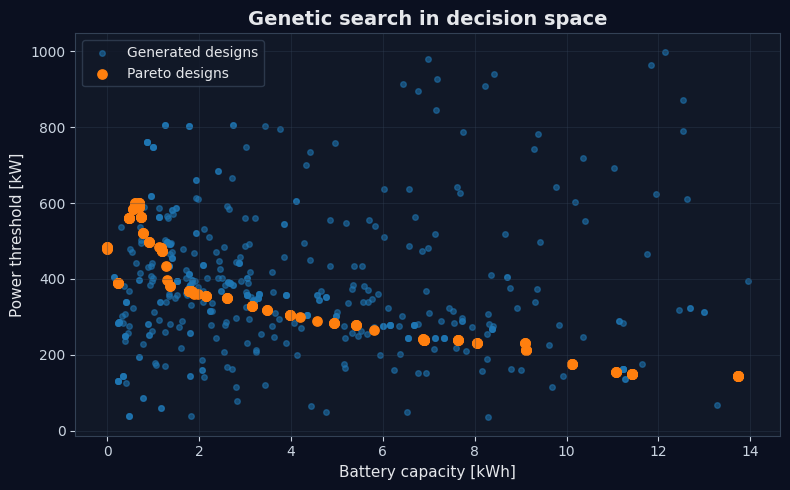

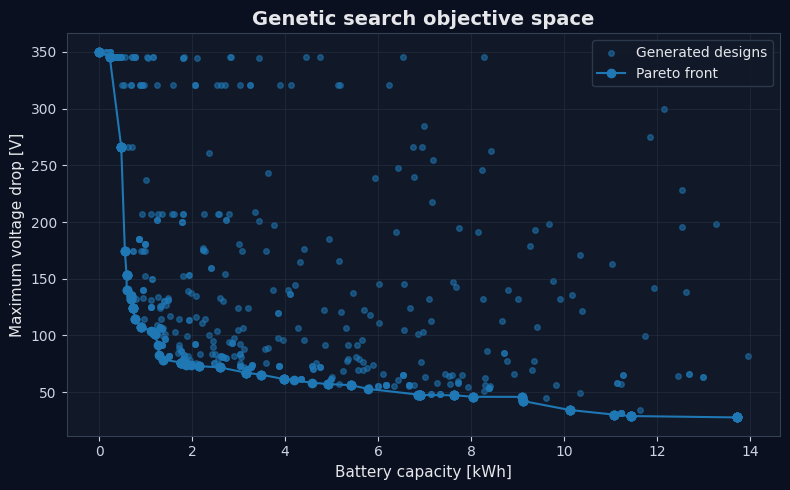

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(
    genetic.capacities_kwh,
    genetic.power_thresholds_kw,
    s=16,
    alpha=0.55,
    label="Generated designs",
)
plt.scatter(
    genetic.pareto_capacities_kwh,
    genetic.pareto_power_thresholds_kw,
    s=45,
    label="Pareto designs",
)
plt.xlabel("Battery capacity [kWh]")
plt.ylabel("Power threshold [kW]")
plt.title("Genetic search in decision space")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(8, 5))
plt.scatter(
    genetic.capacities_kwh,
    genetic.max_voltage_drops_v,
    s=16,
    alpha=0.55,
    label="Generated designs",
)
plt.plot(
    genetic.pareto_capacities_kwh,
    genetic.pareto_voltage_drops_v,
    marker="o",
    label="Pareto front",
)
plt.xlabel("Battery capacity [kWh]")
plt.ylabel("Maximum voltage drop [V]")
plt.title("Genetic search objective space")
plt.legend()
plt.grid(True)
plt.tight_layout()


## 6. Comparison of Pareto approximations

The two methods should reveal the same engineering trend:

- small batteries can already reduce the maximum voltage drop significantly
- beyond a certain capacity, the improvement becomes marginal
- the power threshold controls how aggressively the battery is used


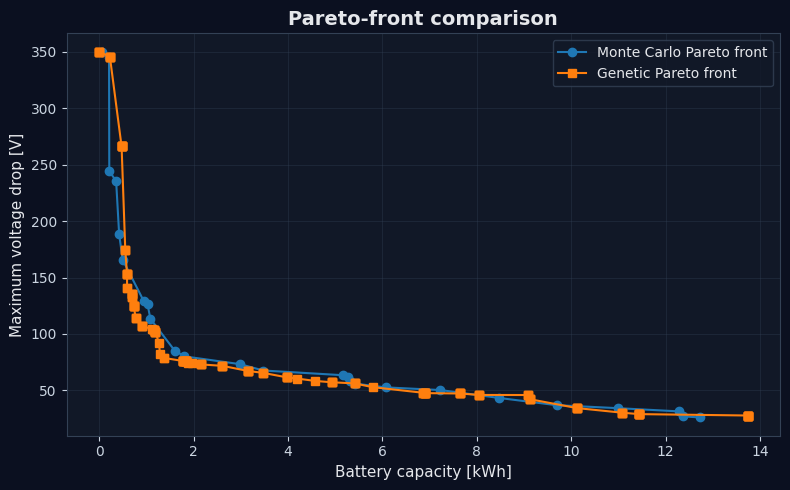

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    monte_carlo.pareto_capacities_kwh,
    monte_carlo.pareto_voltage_drops_v,
    marker="o",
    label="Monte Carlo Pareto front",
)
plt.plot(
    genetic.pareto_capacities_kwh,
    genetic.pareto_voltage_drops_v,
    marker="s",
    label="Genetic Pareto front",
)
plt.xlabel("Battery capacity [kWh]")
plt.ylabel("Maximum voltage drop [V]")
plt.title("Pareto-front comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()


In [14]:
# Display a few compact Pareto candidates from the genetic search.
order = np.argsort(genetic.pareto_capacities_kwh)
summary_rows = []

for idx in order[:10]:
    summary_rows.append(
        (
            genetic.pareto_capacities_kwh[idx],
            genetic.pareto_power_thresholds_kw[idx],
            genetic.pareto_voltage_drops_v[idx],
        )
    )

print("First Pareto candidates from the genetic search:")
print("capacity_kWh | threshold_kW | max_voltage_drop_V")
for capacity, threshold, drop in summary_rows:
    print(f"{capacity:12.3f} | {threshold:12.1f} | {drop:18.1f}")


First Pareto candidates from the genetic search:
capacity_kWh | threshold_kW | max_voltage_drop_V
       0.000 |        479.0 |              350.2
       0.000 |        484.4 |              350.2
       0.000 |        484.4 |              350.2
       0.000 |        484.4 |              350.2
       0.000 |        479.0 |              350.2
       0.229 |        389.6 |              345.7
       0.229 |        389.6 |              345.7
       0.229 |        389.6 |              345.7
       0.229 |        389.6 |              345.7
       0.229 |        389.6 |              345.7


## 7. Engineering interpretation

The battery acts as a peak-shaving device:

- during braking, it captures energy that would otherwise be dissipated
- during high traction demand, it reduces the power drawn from the line
- reducing line power reduces the voltage drop caused by the equivalent network resistance

The relevant design is therefore not the largest battery, but a compromise near the elbow of the Pareto front.
A good design should provide most of the voltage-drop reduction with limited additional capacity.

## 8. Next improvements

Possible extensions:

- implement full NSGA-II with crowding distance and elitism
- add power limits for the battery converter
- test multiple initial states of charge
- compare several control strategies